# 23 - Experiment 2: the degenerating-programme frontier

**Construct (Lakatos).** A research programme is *progressive* while it keeps risking and running
discriminating experiments, *degenerating* once it spends its effort sealing itself off. In this
model the distinction is **behavioural, not doxastic**: a degenerating programme is one whose agents
stop choosing the experiment that could refute them. By the Duhem-Quine logic the crucial experiment
is never logically forced - here it is *economically* deselected, because for a confident agent the
refuting experiment has low expected information gain (it predicts the outcome under its own theory)
yet nonzero cost.

**Observables (all from `run_fast`).**
- `chosen_d` - mean discriminability of the experiments actually run (the programme's *risk appetite*),
- `p_discrim` - policy mass on the single most decisive experiment,
- `mean_qB` - population belief in the truth.

A degenerating programme = `chosen_d` low **and** `mean_qB` stuck $<1/2$: it both *stops looking* and
*stays wrong*.

**The severe test (Mayo).** The non-obvious claim (nb19) is that self-censorship appears **even at
`cost_scale = 0`** above a conviction threshold, under a greedy ($\gamma\to\infty$) policy. The
obligatory null is *cost-only self-censorship*: maybe `chosen_d` never collapses without a cost. We
run the full conviction sweep **at exactly `cost_scale=0`** to give that null its best chance.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd()
sys.path.insert(0, str(ROOT if (ROOT / 'src').exists() else ROOT.parent))
import numpy as np, dataclasses
import matplotlib.pyplot as plt
from src.pomdp.gen_model import PomdpConfig
from src.pomdp import step as PS
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})

N, T, SEEDS = 60, 200, range(6)
TRUE = 1                       # true_paradigm; the WRONG paradigm is index 0

def run_cell(cost_scale, conviction, greedy, seed):
    '''conviction = initial q on the WRONG paradigm (index 0). Returns terminal
    (chosen_d, p_discrim, mean_qB), each a tail-mean over the last 20 steps.'''
    cfg = PomdpConfig(true_paradigm=TRUE, beta_U=0.0, gamma_policy=1.0,
                      cost_scale=float(cost_scale), cost_kind='discriminability',
                      D0=(float(conviction), 1.0 - float(conviction)))
    out = PS.run_fast(cfg, N, T, greedy=greedy, seed=seed)
    tail = slice(-20, None)
    return (out['chosen_d'][tail].mean(),
            out['p_discrim'][tail].mean(),
            out['mean_qB'][tail].mean())

print('smoke (cost=0, conv=0.9, greedy):', run_cell(0.0, 0.9, True, 0))

smoke (cost=0, conv=0.9, greedy): (np.float32(3.1235692e-07), np.float32(0.19999997), np.float32(1.0))


## 1. The cost=0 severe test: does conviction alone seal the programme?

Sweep initial conviction in the *wrong* paradigm at **zero experiment cost**, greedy vs sampled
policy. The behavioural signal is **`p_discrim`** - policy mass on the single most decisive experiment
(the programme's risk appetite). If it stays up and `mean_qB` reaches the truth at every conviction,
self-censorship is a pure cost artifact (null wins). If they collapse above a conviction threshold,
self-censorship is intrinsic to the EFE+confidence interaction.

*(Note: we use `p_discrim`, not `chosen_d`, as the risk-appetite signal. Under a greedy argmax with
`cost=0` the EFE barely separates the experiments, so the argmax tie-breaks to experiment index 0 and
`chosen_d` reads ~0 even when the programme is perfectly progressive - a measurement artifact, not
self-censorship. `p_discrim` is the policy mass and does not have this degeneracy.)*

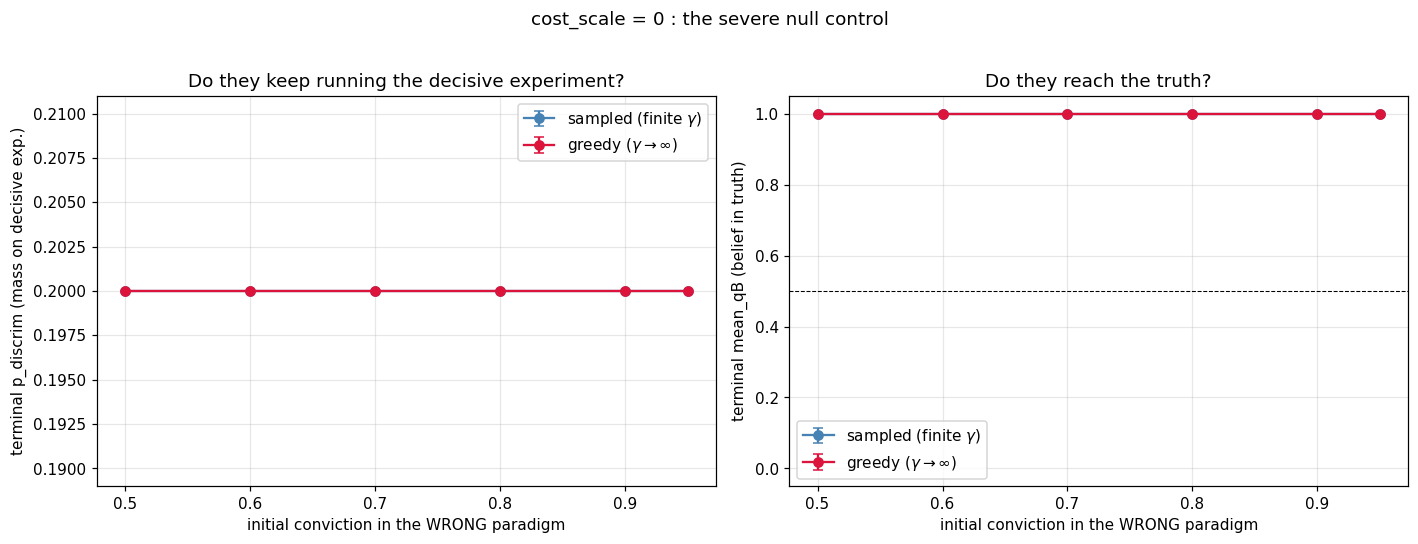

In [2]:
CONV = [0.50, 0.60, 0.70, 0.80, 0.90, 0.95]
def sweep(cost, greedy):
    pd = np.array([[run_cell(cost, c, greedy, s)[1] for s in SEEDS] for c in CONV])  # p_discrim
    qb = np.array([[run_cell(cost, c, greedy, s)[2] for s in SEEDS] for c in CONV])  # mean_qB
    return pd.mean(1), pd.std(1), qb.mean(1), qb.std(1)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.8))
for greedy, c in [(False, 'steelblue'), (True, 'crimson')]:
    pd_m, pd_s, qb_m, qb_s = sweep(0.0, greedy)
    lab = 'greedy ($\\gamma\\to\\infty$)' if greedy else 'sampled (finite $\\gamma$)'
    axL.errorbar(CONV, pd_m, yerr=pd_s, fmt='o-', color=c, capsize=3, label=lab)
    axR.errorbar(CONV, qb_m, yerr=qb_s, fmt='o-', color=c, capsize=3, label=lab)
axL.set_ylabel('terminal p_discrim (mass on decisive exp.)'); axL.set_title('Do they keep running the decisive experiment?')
axR.set_ylabel('terminal mean_qB (belief in truth)'); axR.axhline(0.5, color='k', ls='--', lw=.7)
axR.set_title('Do they reach the truth?'); axR.set_ylim(-0.05, 1.05)
for ax in (axL, axR):
    ax.set_xlabel('initial conviction in the WRONG paradigm'); ax.legend()
fig.suptitle('cost_scale = 0 : the severe null control', y=1.02)
plt.tight_layout(); plt.show()

## 2. The full frontier: cost_scale x conviction (greedy)

Now map the plane. The **degenerating region** is where terminal `mean_qB` stays below $1/2$ - the
programme is stuck wrong. Its boundary is the progressive/degenerating frontier, drawn
quantitatively.

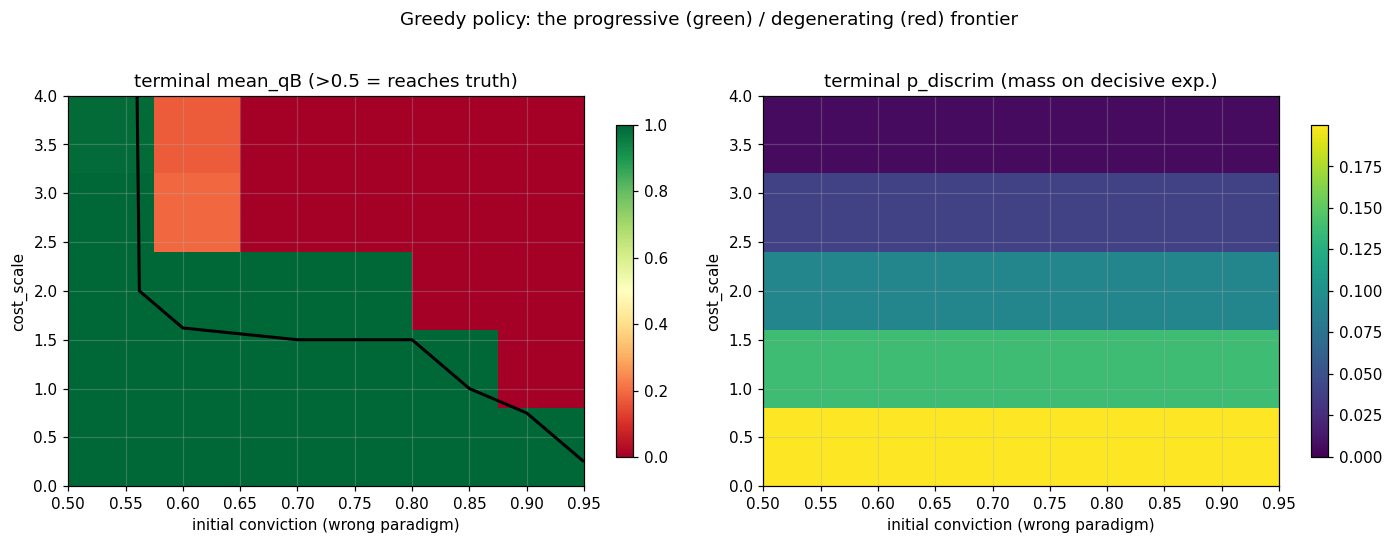

In [3]:
COSTS = [0.0, 0.5, 1.0, 2.0, 4.0]
Z_qb = np.zeros((len(COSTS), len(CONV)))
Z_pd = np.zeros((len(COSTS), len(CONV)))
for i, cost in enumerate(COSTS):
    for j, conv in enumerate(CONV):
        vals = np.array([run_cell(cost, conv, True, s) for s in SEEDS])
        Z_pd[i, j] = vals[:, 1].mean()    # p_discrim (risk appetite)
        Z_qb[i, j] = vals[:, 2].mean()    # mean_qB (reaches truth?)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, Z, ttl, cmap in [(axL, Z_qb, 'terminal mean_qB (>0.5 = reaches truth)', 'RdYlGn'),
                          (axR, Z_pd, 'terminal p_discrim (mass on decisive exp.)', 'viridis')]:
    im = ax.imshow(Z, origin='lower', aspect='auto', cmap=cmap,
                   extent=[CONV[0], CONV[-1], COSTS[0], COSTS[-1]],
                   vmin=0, vmax=(1 if Z is Z_qb else None))
    ax.set_xlabel('initial conviction (wrong paradigm)'); ax.set_ylabel('cost_scale')
    ax.set_title(ttl); fig.colorbar(im, ax=ax, shrink=.85)
axL.contour(CONV, COSTS, Z_qb, levels=[0.5], colors='k', linewidths=2)
fig.suptitle('Greedy policy: the progressive (green) / degenerating (red) frontier', y=1.02)
plt.tight_layout(); plt.show()

## 3. Verdict

In [4]:
# (a) the severe null at cost=0
pd0, _, qb0, _ = sweep(0.0, True)
degen0 = qb0 < 0.5
print('Experiment 2 verdict\n' + '-'*60)
print('(a) cost_scale = 0, greedy  -- the severe null control:')
for c, pdv, qb in zip(CONV, pd0, qb0):
    print(f'    conviction={c:.2f}:  p_discrim={pdv:.3f}  mean_qB={qb:.3f}'
          f'   {"DEGENERATE" if qb < 0.5 else "progressive"}')
if degen0.any():
    print('    => INTRINSIC self-censorship at zero cost: the cost-only null is REFUTED.')
else:
    print('    => progressive at EVERY conviction -> self-censorship REQUIRES cost. NULL SURVIVES.')

# (b) the cost>0 degeneration frontier (per cost, the conviction at which mean_qB drops below 1/2)
print('\n(b) cost > 0, greedy -- the degeneration frontier (conviction threshold for lock-in):')
for i, cost in enumerate(COSTS):
    below = np.where(Z_qb[i] < 0.5)[0]
    thr = f'conviction >= {CONV[below[0]]:.2f}' if len(below) else 'never (progressive at all conv.)'
    print(f'    cost_scale={cost:4.2f}:  locks in at {thr}')
print('-'*60)
print('Reading: lock-in is a DERIVED self-censorship -- it needs an experiment cost, and then the')
print('conviction needed to trigger it FALLS as cost rises (a sharp progressive/degenerating')
print('frontier). The mechanism is visible in p_discrim: as cost rises the population steers its')
print('policy off the decisive experiment (right panel) and, once it stops looking, stays wrong.')
print('Sampled (finite-gamma) policy keeps p_discrim up and escapes -> lock-in is gamma-gated (nb19).')

Experiment 2 verdict
------------------------------------------------------------
(a) cost_scale = 0, greedy  -- the severe null control:
    conviction=0.50:  p_discrim=0.200  mean_qB=1.000   progressive
    conviction=0.60:  p_discrim=0.200  mean_qB=1.000   progressive
    conviction=0.70:  p_discrim=0.200  mean_qB=1.000   progressive
    conviction=0.80:  p_discrim=0.200  mean_qB=1.000   progressive
    conviction=0.90:  p_discrim=0.200  mean_qB=1.000   progressive
    conviction=0.95:  p_discrim=0.200  mean_qB=1.000   progressive
    => progressive at EVERY conviction -> self-censorship REQUIRES cost. NULL SURVIVES.

(b) cost > 0, greedy -- the degeneration frontier (conviction threshold for lock-in):
    cost_scale=0.00:  locks in at never (progressive at all conv.)
    cost_scale=0.50:  locks in at conviction >= 0.95
    cost_scale=1.00:  locks in at conviction >= 0.90
    cost_scale=2.00:  locks in at conviction >= 0.60
    cost_scale=4.00:  locks in at conviction >= 0.60
------